# YOLOv8s WebUI Detection - Simplified Pipeline

This notebook implements WebUI element detection using YOLOv8s with a simplified approach:
- **Uses accessibility tree roles** instead of CSS-based classification
- **Top 10 semantic classes** for reduced class imbalance
- **70/30 train/val split** for better validation
- **YOLOv8s** for improved model capacity
- **Minimum bbox size filter** (w, h >= 10px) to reduce noise

## 1. Setup and Imports

In [1]:
import os
import gzip
import json
import shutil
import random
from pathlib import Path
from collections import Counter
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

# Paths
RAW_DATA_DIR = Path("/mnt/c/WebUIDetection/webui-7k/train_split_web7k")
OUTPUT_DIR = Path("/mnt/c/WebUIDetection/datasets/webui_v2")
IMAGE_WIDTH = 1920
IMAGE_HEIGHT = 1080
MIN_BBOX_SIZE = 10  # Minimum width/height in pixels

## 2. Define Target Classes

Based on dataset analysis, we select the top 10 most frequent **semantic** UI element types from accessibility tree roles, excluding generic roles like 'none', 'generic', 'StaticText', and 'RootWebArea'.

In [2]:
# Top 10 semantic UI element classes
# Selected based on frequency and semantic meaning for UI detection
TARGET_CLASSES = [
    "link",       # Hyperlinks (most common interactive element)
    "button",     # Buttons (key interactive element, lower count but important)
    "img",        # Images
    "heading",    # Headings (h1-h6)
    "listitem",   # List items
    "textbox",    # Text input fields
    "navigation", # Navigation elements
    "banner",     # Header/banner areas
    "paragraph",  # Text paragraphs
    "gridcell",   # Grid/table cells
]

# Create class to ID mapping
CLASS_TO_ID = {cls: idx for idx, cls in enumerate(TARGET_CLASSES)}
ID_TO_CLASS = {idx: cls for cls, idx in CLASS_TO_ID.items()}

print("Target classes:")
for cls, idx in CLASS_TO_ID.items():
    print(f"  {idx}: {cls}")

Target classes:
  0: link
  1: button
  2: img
  3: heading
  4: listitem
  5: textbox
  6: navigation
  7: banner
  8: paragraph
  9: gridcell


## 3. Data Extraction Functions

In [3]:
def load_sample_data(sample_dir: Path) -> tuple:
    """
    Load accessibility tree and bounding box data for a sample.
    
    Returns:
        Tuple of (axtree_data, bb_data, image_path) or (None, None, None) if error
    """
    axtree_file = sample_dir / "default_1920-1080-axtree.json.gz"
    bb_file = sample_dir / "default_1920-1080-bb.json.gz"
    image_file = sample_dir / "default_1920-1080-screenshot.webp"
    
    if not all([axtree_file.exists(), bb_file.exists(), image_file.exists()]):
        return None, None, None
    
    try:
        with gzip.open(axtree_file, 'rt') as f:
            axtree_data = json.load(f)
        
        with gzip.open(bb_file, 'rt') as f:
            bb_data = json.load(f)
        
        return axtree_data, bb_data, image_file
    except Exception as e:
        print(f"Error loading {sample_dir}: {e}")
        return None, None, None


def extract_elements(axtree_data: dict, bb_data: dict) -> list:
    """
    Extract UI elements with their bounding boxes and roles.
    
    Returns:
        List of dicts with keys: role, class_id, x, y, width, height
    """
    elements = []
    bb_ids = set(bb_data.keys())
    
    if 'nodes' not in axtree_data:
        return elements
    
    for node in axtree_data['nodes']:
        if not isinstance(node, dict):
            continue
        
        # Extract role
        role_data = node.get('role', {})
        if isinstance(role_data, dict):
            role = role_data.get('value', '')
        else:
            role = str(role_data) if role_data else ''
        
        # Skip if not in target classes
        if role not in CLASS_TO_ID:
            continue
        
        # Get backend DOM node ID
        backend_id = str(node.get('backendDOMNodeId', ''))
        
        # Check if we have a bounding box
        if backend_id not in bb_ids:
            continue
        
        bbox = bb_data[backend_id]
        if not isinstance(bbox, dict):
            continue
        
        x = bbox.get('x', 0)
        y = bbox.get('y', 0)
        w = bbox.get('width', 0)
        h = bbox.get('height', 0)
        
        # Filter by minimum size
        if w < MIN_BBOX_SIZE or h < MIN_BBOX_SIZE:
            continue
        
        # Filter elements outside viewport
        if x + w <= 0 or y + h <= 0 or x >= IMAGE_WIDTH or y >= IMAGE_HEIGHT:
            continue
        
        elements.append({
            'role': role,
            'class_id': CLASS_TO_ID[role],
            'x': x,
            'y': y,
            'width': w,
            'height': h
        })
    
    return elements


def convert_to_yolo_format(elements: list) -> list:
    """
    Convert bounding boxes to YOLO format (normalized x_center, y_center, width, height).
    
    Returns:
        List of strings in YOLO format: "class_id x_center y_center width height"
    """
    yolo_lines = []
    
    for elem in elements:
        x = elem['x']
        y = elem['y']
        w = elem['width']
        h = elem['height']
        
        # Clamp to viewport
        x = max(0, x)
        y = max(0, y)
        if x + w > IMAGE_WIDTH:
            w = IMAGE_WIDTH - x
        if y + h > IMAGE_HEIGHT:
            h = IMAGE_HEIGHT - y
        
        # Skip if too small after clamping
        if w < MIN_BBOX_SIZE or h < MIN_BBOX_SIZE:
            continue
        
        # Convert to YOLO format (normalized center coordinates)
        x_center = (x + w / 2) / IMAGE_WIDTH
        y_center = (y + h / 2) / IMAGE_HEIGHT
        w_norm = w / IMAGE_WIDTH
        h_norm = h / IMAGE_HEIGHT
        
        # Ensure values are in valid range
        x_center = max(0, min(1, x_center))
        y_center = max(0, min(1, y_center))
        w_norm = max(0, min(1, w_norm))
        h_norm = max(0, min(1, h_norm))
        
        yolo_lines.append(f"{elem['class_id']} {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}")
    
    return yolo_lines

## 4. Process Dataset and Create YOLO Format

In [4]:
def prepare_yolo_dataset(raw_dir: Path, output_dir: Path, train_ratio: float = 0.70):
    """
    Process raw dataset and create YOLO-format dataset with train/val split.
    """
    # Create output directories
    train_images_dir = output_dir / "images" / "train"
    val_images_dir = output_dir / "images" / "val"
    train_labels_dir = output_dir / "labels" / "train"
    val_labels_dir = output_dir / "labels" / "val"
    
    for d in [train_images_dir, val_images_dir, train_labels_dir, val_labels_dir]:
        d.mkdir(parents=True, exist_ok=True)
    
    # Get all sample directories
    sample_dirs = [d for d in raw_dir.iterdir() if d.is_dir()]
    random.shuffle(sample_dirs)
    
    print(f"Total samples: {len(sample_dirs)}")
    
    # Track statistics
    stats = {
        'total_processed': 0,
        'train_samples': 0,
        'val_samples': 0,
        'skipped_no_data': 0,
        'skipped_no_elements': 0,
        'class_counts': Counter()
    }
    
    for i, sample_dir in enumerate(tqdm(sample_dirs, desc="Processing samples")):
        # Load data
        axtree_data, bb_data, image_path = load_sample_data(sample_dir)
        
        if axtree_data is None:
            stats['skipped_no_data'] += 1
            continue
        
        # Extract elements
        elements = extract_elements(axtree_data, bb_data)
        
        if not elements:
            stats['skipped_no_elements'] += 1
            continue
        
        # Convert to YOLO format
        yolo_lines = convert_to_yolo_format(elements)
        
        if not yolo_lines:
            stats['skipped_no_elements'] += 1
            continue
        
        # Determine train/val split
        is_train = random.random() < train_ratio
        
        # Set output directories
        if is_train:
            images_dir = train_images_dir
            labels_dir = train_labels_dir
            stats['train_samples'] += 1
        else:
            images_dir = val_images_dir
            labels_dir = val_labels_dir
            stats['val_samples'] += 1
        
        # Generate filename from sample directory name
        filename = sample_dir.name
        
        # Copy image
        dst_image = images_dir / f"{filename}.webp"
        if not dst_image.exists():
            shutil.copy(image_path, dst_image)
        
        # Write labels
        label_file = labels_dir / f"{filename}.txt"
        with open(label_file, 'w') as f:
            f.write('\n'.join(yolo_lines))
        
        # Update class counts
        for elem in elements:
            stats['class_counts'][elem['role']] += 1
        
        stats['total_processed'] += 1
    
    return stats

In [5]:
# Process the dataset
print("Starting dataset conversion...")
stats = prepare_yolo_dataset(RAW_DATA_DIR, OUTPUT_DIR, train_ratio=0.70)

print("\n=== Dataset Statistics ===")
print(f"Total processed: {stats['total_processed']}")
print(f"Train samples: {stats['train_samples']}")
print(f"Val samples: {stats['val_samples']}")
print(f"Skipped (no data): {stats['skipped_no_data']}")
print(f"Skipped (no elements): {stats['skipped_no_elements']}")

print("\n=== Class Distribution ===")
for cls, count in stats['class_counts'].most_common():
    print(f"  {cls}: {count:,}")

# Save stats for future use (avoid reprocessing after kernel restart)
import pickle
stats_file = OUTPUT_DIR / 'dataset_stats.pkl'
with open(stats_file, 'wb') as f:
    pickle.dump(stats, f)
print(f"\n✅ Saved dataset statistics to {stats_file}")
print("💡 You can load this later to skip reprocessing!")

Starting dataset conversion...
Total samples: 6919


Processing samples: 100%|██████████| 6919/6919 [07:39<00:00, 15.05it/s] 


=== Dataset Statistics ===
Total processed: 6743
Train samples: 4775
Val samples: 1968
Skipped (no data): 0
Skipped (no elements): 176

=== Class Distribution ===
  link: 120,374
  listitem: 63,123
  img: 29,462
  heading: 27,039
  paragraph: 25,309
  gridcell: 9,452
  button: 8,337
  navigation: 4,765
  banner: 3,959
  textbox: 2,955

✅ Saved dataset statistics to /mnt/c/WebUIDetection/datasets/webui_v2/dataset_stats.pkl
💡 You can load this later to skip reprocessing!


## 5. Create data.yaml Configuration

## 4b. Quick Load Stats (Skip Dataset Processing)

If the dataset has already been processed and you just need the statistics (e.g., after kernel restart), use this cell to load the saved stats instead of reprocessing everything.

In [5]:
import pickle
from pathlib import Path

# Load saved statistics
stats_file = Path("/mnt/c/WebUIDetection/datasets/webui_v2/dataset_stats.pkl")

if stats_file.exists():
    with open(stats_file, 'rb') as f:
        stats = pickle.load(f)
    
    print("✅ Loaded saved dataset statistics!")
    print("\n=== Dataset Statistics ===")
    print(f"Total processed: {stats['total_processed']}")
    print(f"Train samples: {stats['train_samples']}")
    print(f"Val samples: {stats['val_samples']}")
    print(f"Skipped (no data): {stats['skipped_no_data']}")
    print(f"Skipped (no elements): {stats['skipped_no_elements']}")
    
    print("\n=== Class Distribution ===")
    for cls, count in stats['class_counts'].most_common():
        print(f"  {cls}: {count:,}")
else:
    print("❌ Stats file not found. Please run the dataset processing cell first (Section 4).")

✅ Loaded saved dataset statistics!

=== Dataset Statistics ===
Total processed: 6743
Train samples: 4775
Val samples: 1968
Skipped (no data): 0
Skipped (no elements): 176

=== Class Distribution ===
  link: 120,374
  listitem: 63,123
  img: 29,462
  heading: 27,039
  paragraph: 25,309
  gridcell: 9,452
  button: 8,337
  navigation: 4,765
  banner: 3,959
  textbox: 2,955


In [6]:
# Create data.yaml for YOLO training
yaml_content = f"""path: {OUTPUT_DIR}
train: images/train
val: images/val
nc: {len(TARGET_CLASSES)}
names:
"""

for cls in TARGET_CLASSES:
    yaml_content += f"  - {cls}\n"

yaml_path = OUTPUT_DIR / "data.yaml"
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print("Created data.yaml:")
print(yaml_content)

Created data.yaml:
path: /mnt/c/WebUIDetection/datasets/webui_v2
train: images/train
val: images/val
nc: 10
names:
  - link
  - button
  - img
  - heading
  - listitem
  - textbox
  - navigation
  - banner
  - paragraph
  - gridcell



## 6. Visualize Class Distribution

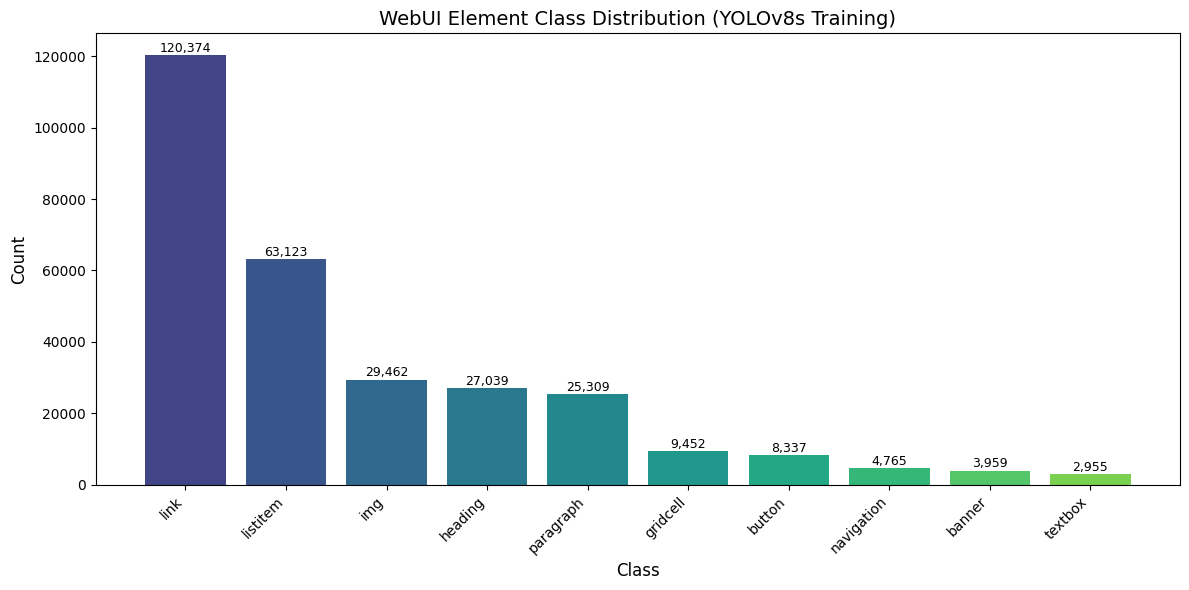

Saved class distribution plot


In [7]:
# Visualize class distribution
plt.figure(figsize=(12, 6))

classes = list(stats['class_counts'].keys())
counts = list(stats['class_counts'].values())

# Sort by count
sorted_data = sorted(zip(classes, counts), key=lambda x: x[1], reverse=True)
classes, counts = zip(*sorted_data)

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(classes)))
bars = plt.bar(classes, counts, color=colors)

plt.xlabel('Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('WebUI Element Class Distribution (YOLOv8s Training)', fontsize=14)
plt.xticks(rotation=45, ha='right')

# Add count labels on bars
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             f'{count:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('/mnt/c/WebUIDetection/class_distribution_v2.png', dpi=150)
plt.show()

print(f"Saved class distribution plot")

## 7. Train YOLOv8s Model

In [ ]:
from ultralytics import YOLO

# Load YOLOv8s pretrained model
model = YOLO('yolov8s.pt')

# Training configuration
# Key changes from previous training:
# - Using YOLOv8s (larger model capacity)
# - 10 classes instead of 20
# - Cleaner labels from accessibility tree
# - Reduced augmentation (no flips for UI detection)
# - Patience=20 for early stopping
# - save_period=10 for checkpoint every 10 epochs

results = model.train(
    data=str(yaml_path),
    epochs=100,
    imgsz=640,
    batch=4,
    patience=20,
    
    # Disable horizontal/vertical flips (UI elements have fixed orientation)
    fliplr=0.0,
    flipud=0.0,
    
    # Reduced augmentation for UI detection
    mosaic=0.3,
    mixup=0.0,
    scale=0.3,
    
    # Checkpoint saving - saves every 10 epochs
    save_period=10,
    
    # Other settings
    verbose=True,
    project='/mnt/c/WebUIDetection/runs',
    name='yolov8s_webui_v2',
    
    # Device (use GPU if available)
    device=0,  # Change to 'cpu' if no GPU
)

New https://pypi.org/project/ultralytics/8.3.248 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.241 🚀 Python-3.10.19 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/mnt/c/WebUIDetection/datasets/webui_v2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=0.3, multi_scale=False

## 7b. Resume Training from Checkpoint (If Kernel Crashed)

Use this cell to resume training from the last saved checkpoint. Checkpoints are saved every 10 epochs in the `weights/` folder as `epoch10.pt`, `epoch20.pt`, etc.

In [ ]:
from ultralytics import YOLO
import os

# ============================================================
# RESUME TRAINING FROM CHECKPOINT
# ============================================================
# Change this to the checkpoint you want to resume from:
# - 'last.pt' for the most recent checkpoint
# - 'epoch10.pt', 'epoch20.pt', etc. for specific epochs
# ============================================================

CHECKPOINT_DIR = '/mnt/c/WebUIDetection/runs/yolov8s_webui_v2/weights'
RESUME_FROM = 'last.pt'  # Options: 'last.pt', 'epoch10.pt', 'epoch20.pt', etc.

checkpoint_path = os.path.join(CHECKPOINT_DIR, RESUME_FROM)

# List available checkpoints
print("Available checkpoints:")
if os.path.exists(CHECKPOINT_DIR):
    checkpoints = [f for f in os.listdir(CHECKPOINT_DIR) if f.endswith('.pt')]
    for ckpt in sorted(checkpoints):
        size_mb = os.path.getsize(os.path.join(CHECKPOINT_DIR, ckpt)) / (1024 * 1024)
        print(f"  - {ckpt} ({size_mb:.1f} MB)")
else:
    print("  No checkpoints found yet. Run training first.")

# Resume training
if os.path.exists(checkpoint_path):
    print(f"\n>>> Resuming training from: {checkpoint_path}")
    
    # Load the checkpoint
    model = YOLO(checkpoint_path)
    
    # Resume training with same parameters
    results = model.train(
        resume=True,  # This tells YOLO to resume from where it left off
    )
    
    print("\nTraining resumed and completed!")
else:
    print(f"\n>>> Checkpoint not found: {checkpoint_path}")
    print(">>> Please run the training cell first, or check the checkpoint name.")

Available checkpoints:
  - best.pt (64.1 MB)
  - last.pt (64.1 MB)

>>> Resuming training from: /mnt/c/WebUIDetection/runs/yolov8s_webui_v2/weights/last.pt


KeyboardInterrupt: 

## 8. Evaluate Model Performance

In [ ]:
# Load best model and evaluate
best_model_path = '/mnt/c/WebUIDetection/runs/yolov8s_webui_v2/weights/best.pt'
model = YOLO(best_model_path)

# Run validation
metrics = model.val()

print("\n=== Model Performance ===")
print(f"mAP50: {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")

Ultralytics 8.3.241 🚀 Python-3.10.19 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
Model summary (fused): 72 layers, 11,129,454 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 2.1±0.3 ms, read: 17.0±4.8 MB/s, size: 73.4 KB)
val: Scanning /mnt/c/WebUIDetection/datasets/webui_v2/labels/val.cache... 1968 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1968/1968 2.1Mit/s 0.0s0s
val: /mnt/c/WebUIDetection/datasets/webui_v2/images/val/1655898128460.webp: 5 duplicate labels removed
val: /mnt/c/WebUIDetection/datasets/webui_v2/images/val/1655906894333.webp: 3 duplicate labels removed
val: /mnt/c/WebUIDetection/datasets/webui_v2/images/val/1655914235020.webp: 3 duplicate labels removed
val: /mnt/c/WebUIDetection/datasets/webui_v2/images/val/1655918461857.webp: 1 duplicate labels removed
val: /mnt/c/WebUIDetection/datasets/webui_v2/images/val/1655920292648.webp: 1 duplicate labels removed
val: /mnt/c/WebUIDetection/datasets/webui_v2/images/val/16

## 9. Per-Class mAP Analysis


=== Per-Class AP50 ===
  link: 0.5399
  button: 0.3294
  img: 0.5324
  heading: 0.6550
  listitem: 0.5920
  textbox: 0.6008
  navigation: 0.2707
  banner: 0.6186
  paragraph: 0.5230
  gridcell: 0.2386


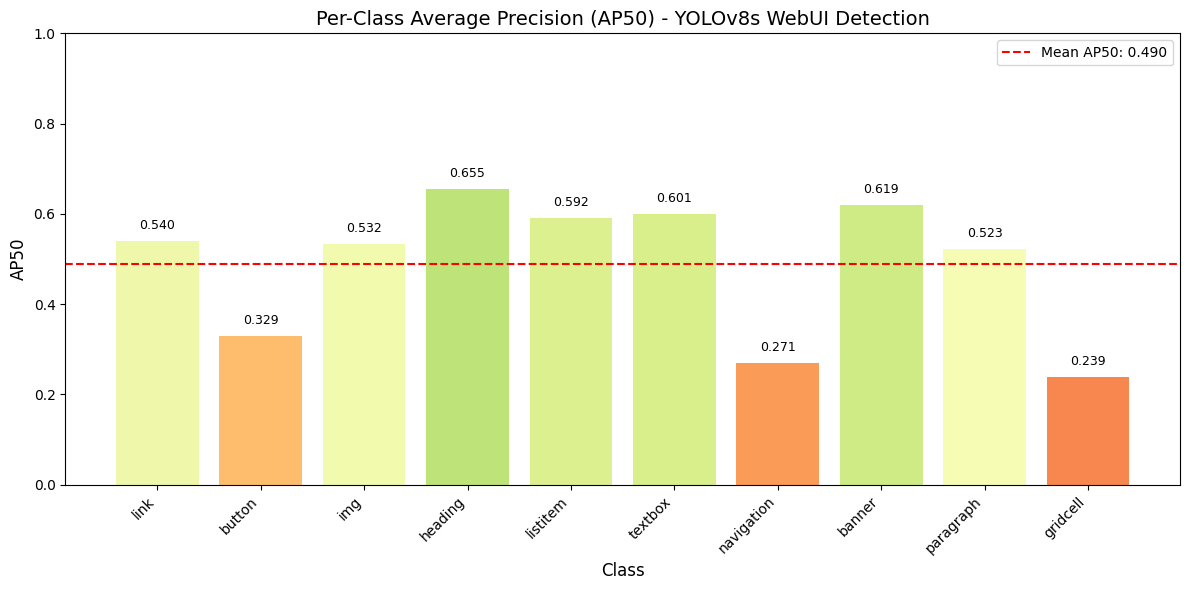

In [ ]:
# Per-class AP breakdown
print("\n=== Per-Class AP50 ===")
for i, cls in enumerate(TARGET_CLASSES):
    if i < len(metrics.box.ap50):
        ap50 = metrics.box.ap50[i]
        print(f"  {cls}: {ap50:.4f}")

# Visualize per-class performance
plt.figure(figsize=(12, 6))

ap50_values = [metrics.box.ap50[i] if i < len(metrics.box.ap50) else 0 for i in range(len(TARGET_CLASSES))]
colors = plt.cm.RdYlGn(np.array(ap50_values))

bars = plt.bar(TARGET_CLASSES, ap50_values, color=colors)
plt.axhline(y=metrics.box.map50, color='red', linestyle='--', label=f'Mean AP50: {metrics.box.map50:.3f}')

plt.xlabel('Class', fontsize=12)
plt.ylabel('AP50', fontsize=12)
plt.title('Per-Class Average Precision (AP50) - YOLOv8s WebUI Detection', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.legend()

# Add value labels
for bar, val in zip(bars, ap50_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('/mnt/c/WebUIDetection/per_class_ap_v2.png', dpi=150)
plt.show()

## 10. Generate Confusion Matrix with Matplotlib

Generating confusion matrix from 3379 validation images...


Processing validation images: 100%|██████████| 3379/3379 [02:36<00:00, 21.53it/s] 


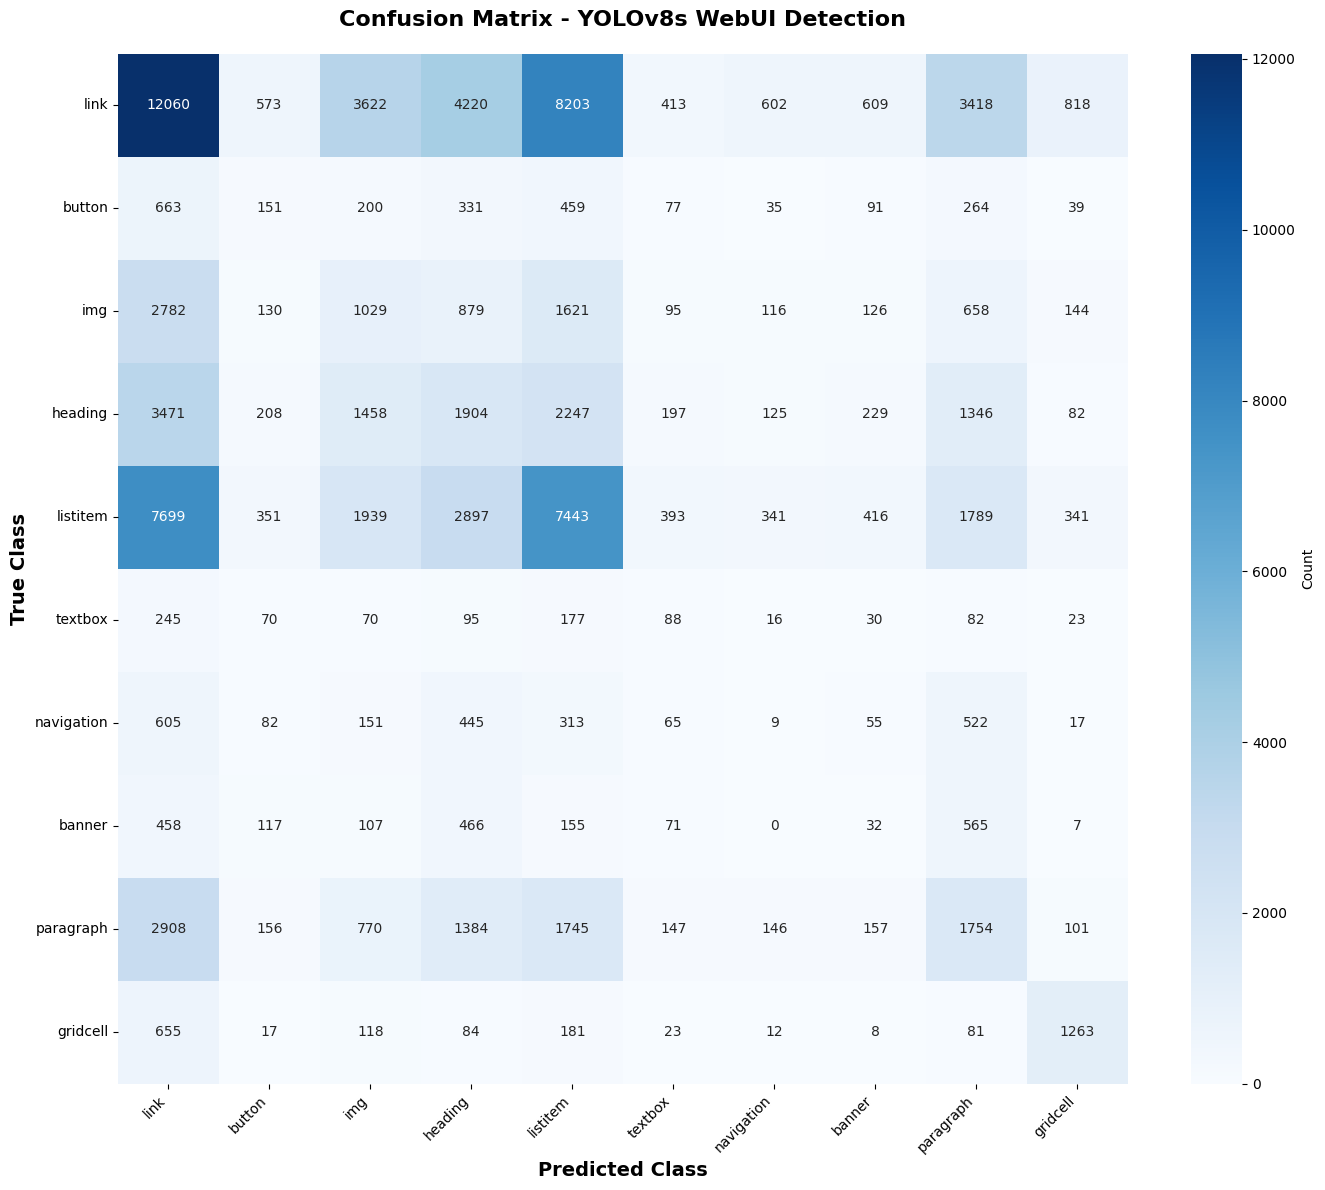


=== Per-Class Accuracy from Confusion Matrix ===
link: 34.92% (12060/34538)
button: 6.54% (151/2310)
img: 13.58% (1029/7580)
heading: 16.90% (1904/11267)
listitem: 31.53% (7443/23609)
textbox: 9.82% (88/896)
navigation: 0.40% (9/2264)
banner: 1.62% (32/1978)
paragraph: 18.93% (1754/9268)
gridcell: 51.72% (1263/2442)


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get predictions on validation set
val_images_dir = OUTPUT_DIR / "images" / "val"
val_images = list(val_images_dir.glob("*.webp"))

print(f"Generating confusion matrix from {len(val_images)} validation images...")

# Collect ground truth and predictions
y_true = []
y_pred = []

for img_path in tqdm(val_images, desc="Processing validation images"):
    # Get ground truth labels from label file
    label_file = OUTPUT_DIR / "labels" / "val" / f"{img_path.stem}.txt"
    
    if label_file.exists():
        with open(label_file, 'r') as f:
            gt_labels = [int(line.split()[0]) for line in f.readlines()]
        
        # Get predictions
        results = model.predict(str(img_path), conf=0.25, verbose=False)
        pred_labels = results[0].boxes.cls.cpu().numpy().astype(int).tolist() if len(results[0].boxes) > 0 else []
        
        # For confusion matrix, we need same length
        # Add ground truth labels and corresponding predictions
        for gt_label in gt_labels:
            y_true.append(gt_label)
            # Find best matching prediction (simplified approach)
            if pred_labels:
                y_pred.append(pred_labels[0])  # Take first prediction
                pred_labels = pred_labels[1:]  # Remove used prediction
            else:
                y_pred.append(-1)  # No prediction (will show as misclassification)

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(TARGET_CLASSES))))

# Plot confusion matrix with matplotlib
fig, ax = plt.subplots(figsize=(14, 12))

# Use seaborn for better visualization
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=TARGET_CLASSES, 
            yticklabels=TARGET_CLASSES,
            cbar_kws={'label': 'Count'},
            ax=ax)

ax.set_xlabel('Predicted Class', fontsize=14, fontweight='bold')
ax.set_ylabel('True Class', fontsize=14, fontweight='bold')
ax.set_title('Confusion Matrix - YOLOv8s WebUI Detection', fontsize=16, fontweight='bold', pad=20)

# Rotate labels for better readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('/mnt/c/WebUIDetection/confusion_matrix_custom.png', dpi=150, bbox_inches='tight')
plt.show()

# Print per-class accuracy
print("\n=== Per-Class Accuracy from Confusion Matrix ===")
for i, cls in enumerate(TARGET_CLASSES):
    if cm[i].sum() > 0:
        accuracy = cm[i, i] / cm[i].sum()
        print(f"{cls}: {accuracy:.2%} ({cm[i, i]}/{cm[i].sum()})")

## 11. Run Inference on Sample Images

Running inference on 5 sample images...


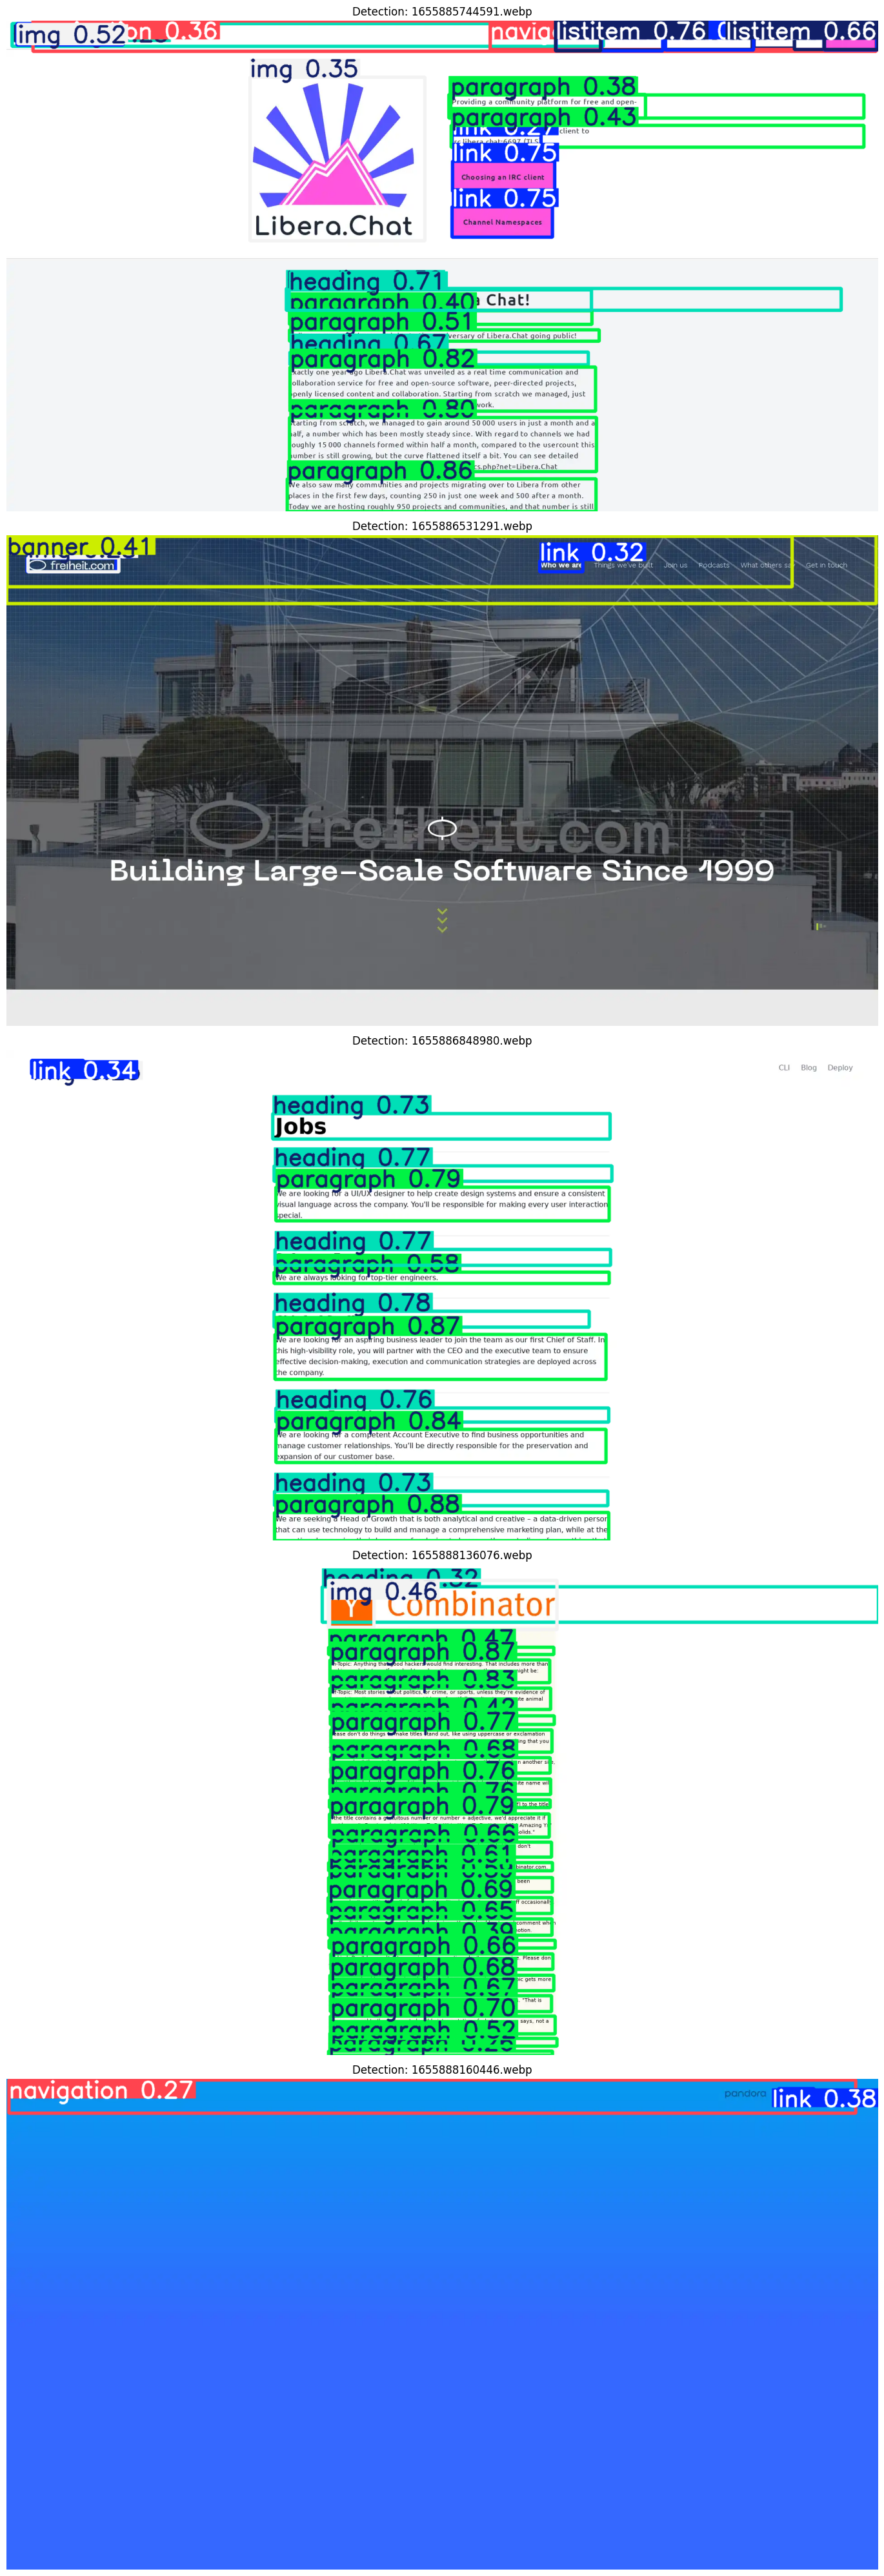

Saved detection results


In [ ]:
# Test inference on validation images
val_images_dir = OUTPUT_DIR / "images" / "val"
sample_images = list(val_images_dir.glob("*.webp"))[:5]

print(f"Running inference on {len(sample_images)} sample images...")

fig, axes = plt.subplots(len(sample_images), 1, figsize=(15, 8*len(sample_images)))
if len(sample_images) == 1:
    axes = [axes]

for ax, img_path in zip(axes, sample_images):
    # Run inference
    results = model.predict(str(img_path), conf=0.25, verbose=False)
    
    # Get annotated image
    annotated = results[0].plot()
    
    ax.imshow(annotated[:, :, ::-1])  # BGR to RGB
    ax.set_title(f"Detection: {img_path.name}")
    ax.axis('off')

plt.tight_layout()
plt.savefig('/mnt/c/WebUIDetection/detection_results_v2.png', dpi=100)
plt.show()

print("Saved detection results")

## 12. Summary and Comparison

### Key Changes from Previous Approach:

1. **Label Source**: Using accessibility tree roles instead of CSS class heuristics
   - Cleaner, more semantic labels
   - Direct mapping from browser accessibility API

2. **Class Count**: 10 classes instead of 20
   - Reduced class imbalance
   - Focus on most frequent semantic elements

3. **Model**: YOLOv8s instead of YOLOv11n
   - Larger model capacity
   - Better feature extraction

4. **Train/Val Split**: 70/30 instead of 85/15
   - Better validation set for performance evaluation

5. **Minimum BBox Filter**: 10px instead of 2px
   - Reduces noise from tiny elements

### Expected Improvements:
- Higher mAP due to cleaner labels
- Better per-class performance due to reduced class imbalance
- More stable training due to semantic labels

In [ ]:
print("\n=== Training Summary ===")
print(f"Model: YOLOv8s")
print(f"Classes: {len(TARGET_CLASSES)}")
print(f"Train samples: {stats['train_samples']}")
print(f"Val samples: {stats['val_samples']}")
print(f"Total annotations: {sum(stats['class_counts'].values()):,}")
print("\nTarget for comparison with previous 16% mAP:")
print(f"Current mAP50: {metrics.box.map50:.4f} ({metrics.box.map50*100:.1f}%)")


=== Training Summary ===
Model: YOLOv8s
Classes: 10
Train samples: 4775
Val samples: 1968
Total annotations: 294,775

Target for comparison with previous 16% mAP:
Current mAP50: 0.4900 (49.0%)
